In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os

In [4]:
dataset = "./brain-tumor-mri-dataset"

print("Folders:", os.listdir(dataset))

dataAug = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

train_data = dataAug.flow_from_directory(
    dataset,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',   # ✅ FIXED
    subset='training'
)

val_data = dataAug.flow_from_directory(
    dataset,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',   # ✅ FIXED
    subset='validation'
)

class_labels = list(train_data.class_indices.keys())
print("Classes:", class_labels)

Folders: ['glioma', 'meningioma', 'notumor', 'pituitary']
Found 5723 images belonging to 4 classes.
Found 1430 images belonging to 4 classes.
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


In [5]:
model = keras.Sequential([
    keras.layers.Conv2D(32,(3,3),activation='relu',input_shape=(224,224,3)),
    keras.layers.MaxPooling2D(2,2),

    keras.layers.Conv2D(64,(3,3),activation='relu'),
    keras.layers.MaxPooling2D(2,2),

    keras.layers.Conv2D(128,(3,3),activation='relu'),
    keras.layers.MaxPooling2D(2,2),

    keras.layers.Flatten(),

    keras.layers.Dense(128,activation='relu'),
    keras.layers.Dropout(0.5),

    keras.layers.Dense(4,activation='softmax')  # ✅ FIXED
])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,476 (42.61 MB)

 Trainable params: 11,169,476 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',  # ✅ FIXED
    metrics=['accuracy']
)

In [9]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

Epoch 1/5
179/179 ━━━━━━━━━━━━━━━━━━━━ 122s 677ms/step - accuracy: 0.6947 - loss: 0.7413 - val_accuracy: 0.7699 - val_loss: 0.5879
Epoch 2/5
179/179 ━━━━━━━━━━━━━━━━━━━━ 117s 656ms/step - accuracy: 0.7444 - loss: 0.6359 - val_accuracy: 0.8042 - val_loss: 0.4987
Epoch 3/5
179/179 ━━━━━━━━━━━━━━━━━━━━ 118s 656ms/step - accuracy: 0.7809 - loss: 0.5450 - val_accuracy: 0.7867 - val_loss: 0.5132
Epoch 4/5
179/179 ━━━━━━━━━━━━━━━━━━━━ 195s 1s/step - accuracy: 0.7921 - loss: 0.5141 - val_accuracy: 0.8231 - val_loss: 0.4284
Epoch 5/5
179/179 ━━━━━━━━━━━━━━━━━━━━ 267s 1s/step - accuracy: 0.8158 - loss: 0.4660 - val_accuracy: 0.8343 - val_loss: 0.4250


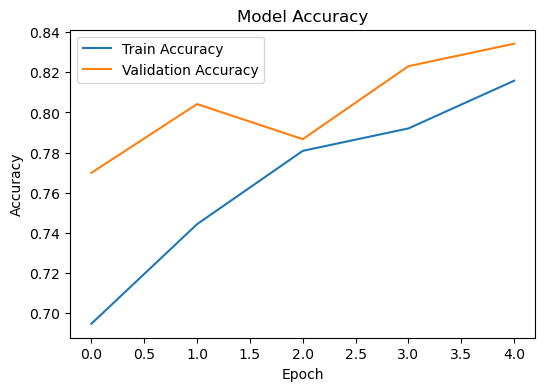

In [10]:
plt.figure(figsize=(6,4))
plt.plot(history.history['accuracy'],label="Train Accuracy")
plt.plot(history.history['val_accuracy'],label="Validation Accuracy")
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

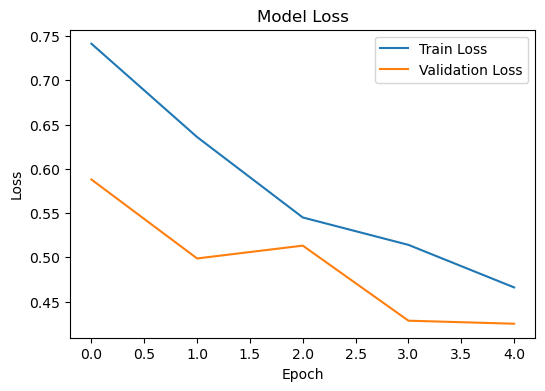

In [11]:
plt.figure(figsize=(6,4))
plt.plot(history.history['loss'],label="Train Loss")
plt.plot(history.history['val_loss'],label="Validation Loss")
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [12]:
val_data.reset()
predictions = model.predict(val_data)

y_pred = np.argmax(predictions, axis=1)
y_true = val_data.classes

45/45 ━━━━━━━━━━━━━━━━━━━━ 13s 295ms/step


In [14]:
print(classification_report(
    y_true,
    y_pred,
    target_names=class_labels
))

              precision    recall  f1-score   support

      glioma       0.23      0.26      0.24       324
  meningioma       0.27      0.22      0.24       355
     notumor       0.33      0.33      0.33       400
   pituitary       0.26      0.27      0.27       351

    accuracy                           0.27      1430
   macro avg       0.27      0.27      0.27      1430
weighted avg       0.27      0.27      0.27      1430

